# CIFAR-10 Image Classification Learning Project


# Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
  3031040/170498071 ━━━━━━━━━━━━━━━━━━━━ 2:40:12 57us/step

## Visualize Sample Images

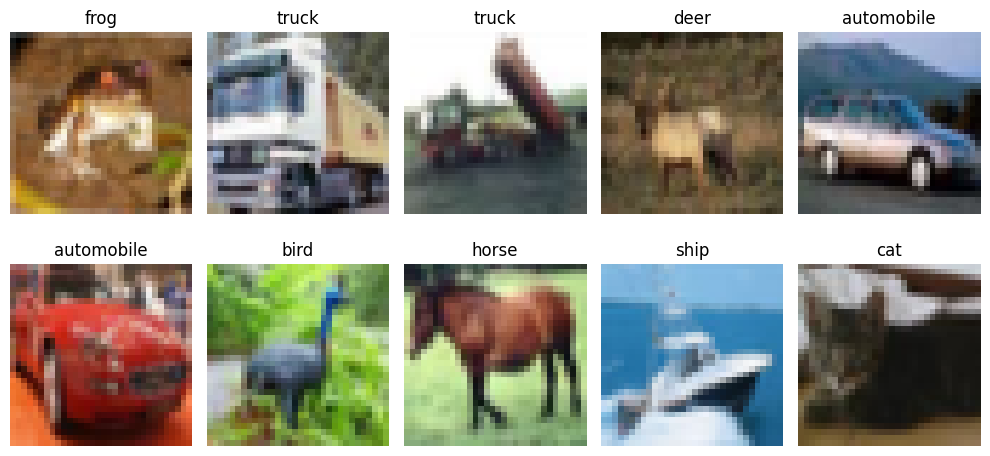

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# Preprocessing

In [4]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# Part 1: Baseline ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
That is why **CNN is better for images**.

The baseline ANN model was trained for 10 epochs using the Adam optimizer and Sparse Categorical Crossentropy loss.

This baseline model serves as a reference point for performance comparison. In the modified ANN model, additional Dense layers and increased training epochs will be introduced to investigate whether a deeper architecture can improve classification accuracy.

In [5]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.2728 - loss: 1.9931 - val_accuracy: 0.3386 - val_loss: 1.8294
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3232 - loss: 1.8575 - val_accuracy: 0.3380 - val_loss: 1.7975
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3388 - loss: 1.8154 - val_accuracy: 0.3664 - val_loss: 1.7661
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3572 - loss: 1.7728 - val_accuracy: 0.3850 - val_loss: 1.7185
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3623 - loss: 1.7624 - val_accuracy: 0.3804 - val_loss: 1.7392
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3615 - loss: 1.7564 - val_accuracy: 0.3954 - val_loss: 1.6973
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 26ms/step - accuracy: 0.3733 - loss: 1.7221 - val_accuracy: 0.4164 - val_loss: 1.6592
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3784 - loss: 1.7059 - 

In [6]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4312 - loss: 1.6344
ANN Test Accuracy: 0.4311999976634979


# Part 2: Baseline CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

The model was trained for 10 epochs using the Adam optimizer and Sparse Categorical Crossentropy loss.

This baseline CNN will be further enhanced in the advanced model by increasing the number of convolutional filters (32→64→128), extending training to 20 epochs, incorporating Early Stopping, and applying data augmentation techniques such as RandomFlip, RandomRotation, and RandomZoom to improve generalization performance.

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 78s 108ms/step - accuracy: 0.4380 - loss: 1.6039 - val_accuracy: 0.5290 - val_loss: 1.3613
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 107ms/step - accuracy: 0.5620 - loss: 1.2394 - val_accuracy: 0.5334 - val_loss: 1.4273
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.6208 - loss: 1.0781 - val_accuracy: 0.6292 - val_loss: 1.0632
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 75s 106ms/step - accuracy: 0.6629 - loss: 0.9608 - val_accuracy: 0.6614 - val_loss: 0.9804
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 104ms/step - accuracy: 0.6935 - loss: 0.8703 - val_accuracy: 0.6054 - val_loss: 1.1872
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 74s 105ms/step - accuracy: 0.7203 - loss: 0.7954 - val_accuracy: 0.6478 - val_loss: 1.0199
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 105ms/step - accuracy: 0.7412 - loss: 0.7324 - val_accuracy: 0.6428 - val_loss: 1.0850
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 73s 104ms/step - accuracy: 0.7567 - loss: 0

In [8]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6946 - loss: 0.9539
CNN Test Accuracy: 0.694599986076355


## Validation Curve comparing ANN and CNN over 10 epochs

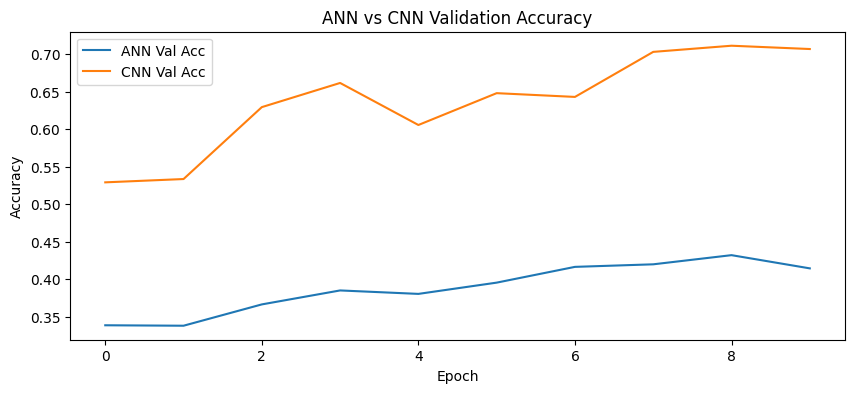

In [9]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

## **Inference from Validation Accuracy Comparison**
- The CNN model achieved higher validation accuracy than the ANN model throughout most of the training process.

- CNN performs better because it preserves the spatial structure of images and automatically learns important visual features such as edges, textures, and shapes.

- ANN treats each pixel as an independent input after flattening the image, causing loss of spatial information.

- The validation accuracy of CNN increased more steadily and converged to a higher value compared to ANN.

- The comparison demonstrates that CNN are more suitable for image classification tasks such as CIFAR-10.

# Part 3: Improved ANN Model
The improved ANN has increased layers and 20 epochs

In [10]:
improved_ann = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

improved_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_ann_history = improved_ann.fit(
    x_train_flat,
    y_train,
    epochs=20,          # Increased from 10 to 20
    batch_size=64,
    validation_split=0.1
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 62ms/step - accuracy: 0.2504 - loss: 2.0319 - val_accuracy: 0.3032 - val_loss: 1.9079
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3107 - loss: 1.8819 - val_accuracy: 0.3526 - val_loss: 1.8100
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 44s 62ms/step - accuracy: 0.3238 - loss: 1.8465 - val_accuracy: 0.3520 - val_loss: 1.8199
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 65ms/step - accuracy: 0.3385 - loss: 1.8059 - val_accuracy: 0.3878 - val_loss: 1.7351
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - accuracy: 0.3461 - loss: 1.7940 - val_accuracy: 0.3694 - val_loss: 1.7693
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3552 - loss: 1.7671 - val_accuracy: 0.3898 - val_loss: 1.7198
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - accuracy: 0.3588 - loss: 1.7522 - val_accuracy: 0.3846 - val_loss: 1.7317
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 62ms/step - accuracy: 0.3676 - loss: 1.7376 - 

In [11]:
improved_ann_test_loss, improved_ann_test_acc = improved_ann.evaluate(x_test_flat, y_test)
print("Improved ANN Test Accuracy:", improved_ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4237 - loss: 1.6311
Improved ANN Test Accuracy: 0.4237000048160553


# 🔹 Part 4: Modified CNN Model
The modified CNN:
- has increased number of convolutional filters (32→64→128)
- has increased number of epochs(10 → 20)
- has applied Data augmentation techniques
- incorporates Early stopping

## **Data Augmentation**
Data augmentation artificially increases the diversity of the training dataset by generating modified versions of existing images during training.

The following augmentation layers were applied:

- **RandomFlip("horizontal"):** Randomly flips images horizontally, helping the model recognize objects irrespective of their orientation.
- **RandomRotation(0.1):** Applies small random rotations to make the model more robust to changes in viewing angles.
- **RandomZoom(0.1):** Randomly zooms images in or out, enabling the model to learn scale-invariant features.

In [12]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
    ])

## **Early Stopping**
Early Stopping continuously monitors the validation performance during training and automatically stops the training process when no significant improvement is observed for a specified number of epochs.

Benefits of Early Stopping:

- Prevents overfitting by stopping training at the optimal point.
- Reduces unnecessary computation and training time.
- Automatically restores the best model weights.
- Improves the model's ability to generalize to unseen data.

In [21]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True)

In [22]:
improved_cnn = models.Sequential([
    layers.Input(shape=(32,32,3)),

    data_augmentation,

    layers.Conv2D(32, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')
])

improved_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_cnn_history = improved_cnn.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop]
)

improved_cnn_test_loss, improved_cnn_test_acc = improved_cnn.evaluate(
    x_test,
    y_test
)

print("Improved CNN Test Accuracy:", improved_cnn_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 146s 201ms/step - accuracy: 0.4274 - loss: 1.6128 - val_accuracy: 0.4850 - val_loss: 1.4938
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 201ms/step - accuracy: 0.5286 - loss: 1.3167 - val_accuracy: 0.5744 - val_loss: 1.2028
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 204ms/step - accuracy: 0.5776 - loss: 1.2000 - val_accuracy: 0.6432 - val_loss: 1.0326
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 201ms/step - accuracy: 0.6124 - loss: 1.0978 - val_accuracy: 0.6218 - val_loss: 1.1203
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 204ms/step - accuracy: 0.6367 - loss: 1.0394 - val_accuracy: 0.6542 - val_loss: 1.0413
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 206ms/step - accuracy: 0.6558 - loss: 0.9904 - val_accuracy: 0.6732 - val_loss: 0.9820
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 201ms/step - accuracy: 0.6713 - loss: 0.9426 - val_accuracy: 0.6718 - val_loss: 0.9994
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 205ms/step - accuracy: 0.6886 -

# 📊 Final Comparison Table

In [27]:
comparison = pd.DataFrame({
    "Model": ["Baseline ANN", "Baseline CNN","Modified ANN","Modified CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc,improved_ann_test_acc,improved_cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,Baseline ANN,0.4312
1,Baseline CNN,0.6946
2,Modified ANN,0.4237
3,Modified CNN,0.7384


## **Key Observations**
**1. CNN significantly outperformed ANN**

This demonstrates that CNNs are much more effective for image classification because they preserve spatial information and learn visual features automatically.

**2. Modified CNN achieved the best performance**

The increase can be attributed to:

- Additional convolutional layer (128 filters)
- Data augmentation
- Longer training (20 epochs)
- EarlyStopping

**3. Modified ANN did not improve**
- Accuracy decreased slightly from 43.12% → 42.37%.
- This shows that increasing Dense layers alone does not necessarily improve performance on image datasets.
- Since ANN operates on flattened pixel values, it cannot effectively capture spatial relationships between pixels.